In [20]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv(
    r"C:\Users\USER\OneDrive\Desktop\AI-Financial-Risk-Intelligence\data\raw\bank+marketing\bank\bank-full.csv",
    sep=";",
)

In [22]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# Exploratory Data Analysis: Bank Marketing Dataset

This analysis covers dataset structure, data quality, target balance, numerical and categorical distributions, outliers, campaign behavior, previous-contact outcomes, feature relationships, and business-oriented findings.

In [23]:
# 1. Dataset overview and data-quality audit
n_rows, n_cols = df.shape
print(f"Rows: {n_rows:,}")
print(f"Columns: {n_cols}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_rate": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(),
}).sort_values("missing_rate", ascending=False)
display(audit)

print("\nRows with explicit 'unknown' values by column:")
unknown_counts = df.select_dtypes(include="object").apply(
    lambda column: column.astype(str).str.lower().eq("unknown").sum()
    ).sort_values(ascending=False)
display(unknown_counts[unknown_counts > 0].to_frame("unknown_count"))

Rows: 45,211
Columns: 17
Duplicate rows: 0
Memory usage: 8.07 MB


,dtype,missing_count,missing_rate,unique_values
age,int64,0,0.0,77
job,str,0,0.0,12
marital,str,0,0.0,3
education,str,0,0.0,4
default,str,0,0.0,2
balance,int64,0,0.0,7168
housing,str,0,0.0,2
loan,str,0,0.0,2
contact,str,0,0.0,3
day,int64,0,0.0,31



Rows with explicit 'unknown' values by column:


C:\Users\USER\AppData\Local\Temp\ipykernel_13440\3862045015.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  unknown_counts = df.select_dtypes(include="object").apply(


,unknown_count
poutcome,36959
contact,13020
education,1857
job,288


Subscription counts:


,count
y,
no,39922
yes,5289


Subscription rates (%):


,rate
y,
no,88.3
yes,11.7


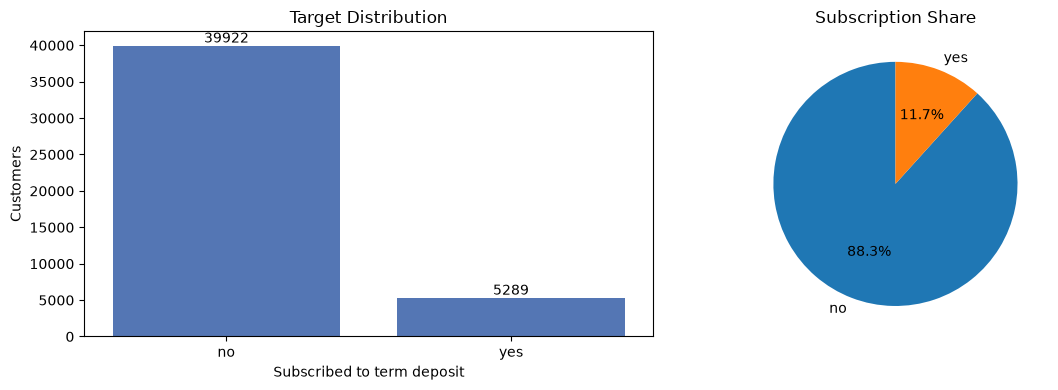

In [24]:
# 2. Target analysis: subscription outcome
target_counts = df["y"].value_counts().reindex(["no", "yes"]).fillna(0)
target_rates = (target_counts / len(df) * 100).round(2)
print("Subscription counts:")
display(target_counts.to_frame("count"))
print("Subscription rates (%):")
display(target_rates.to_frame("rate"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="y", order=["no", "yes"], ax=axes[0], color="#4472C4")
axes[0].set_title("Target Distribution")
axes[0].set_xlabel("Subscribed to term deposit")
axes[0].set_ylabel("Customers")
for container in axes[0].containers:
    axes[0].bar_label(container)

axes[1].pie(target_counts, labels=target_counts.index, autopct="%.1f%%", startangle=90)
axes[1].set_title("Subscription Share")
plt.tight_layout()
plt.show()

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


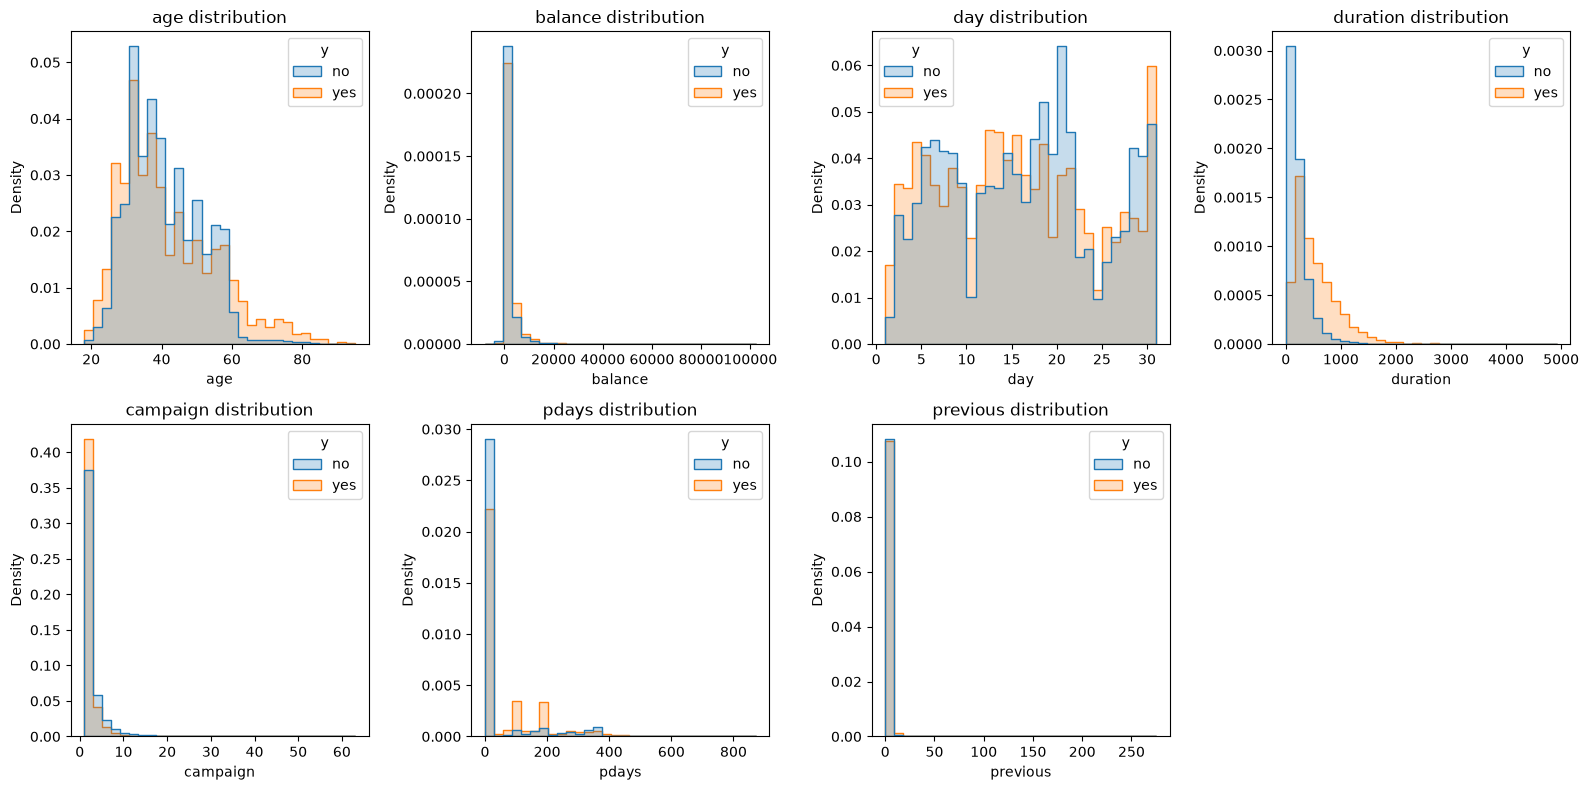

IQR-based outlier summary:


,feature,lower_bound,upper_bound,outlier_count,outlier_rate_%
0,age,10.5,70.5,487,1.08
1,balance,-1962.0,3462.0,4729,10.46
2,duration,-221.0,643.0,3235,7.16
3,campaign,-2.0,6.0,3064,6.78
4,pdays,-1.0,-1.0,8257,18.26
5,previous,0.0,0.0,8257,18.26


pdays sentinel value (-1) rate: 81.74%


In [25]:
# 3. Numerical distributions and outlier review
numeric_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
display(df[numeric_cols].describe().T)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for axis, column in zip(axes.flat, numeric_cols):
    sns.histplot(data=df, x=column, hue="y", bins=30, element="step", stat="density", common_norm=False, ax=axis)
    axis.set_title(f"{column} distribution")
for axis in axes.flat[len(numeric_cols):]:
    axis.set_visible(False)
plt.tight_layout()
plt.show()

outlier_rows = []
for column in ["age", "balance", "duration", "campaign", "pdays", "previous"]:
    q1, q3 = df[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((df[column] < lower) | (df[column] > upper)).sum()
    outlier_rows.append({"feature": column, "lower_bound": lower, "upper_bound": upper, "outlier_count": count, "outlier_rate_%": round(count / len(df) * 100, 2)})
print("IQR-based outlier summary:")
display(pd.DataFrame(outlier_rows))

print("pdays sentinel value (-1) rate:", f"{(df['pdays'] == -1).mean() * 100:.2f}%")


job - categories: 12


C:\Users\USER\AppData\Local\Temp\ipykernel_13440\3757656007.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = [column for column in df.select_dtypes(include="object").columns if column != "y"]


,customers,subscriptions,subscription_rate_%
job,,,
student,938,269,28.68
retired,2264,516,22.79
unemployed,1303,202,15.50
management,9458,1301,13.76
admin.,5171,631,12.20
self-employed,1579,187,11.84
unknown,288,34,11.81
technician,7597,840,11.06
services,4154,369,8.88



marital - categories: 3


,customers,subscriptions,subscription_rate_%
marital,,,
single,12790,1912,14.95
divorced,5207,622,11.95
married,27214,2755,10.12


...

,customers,subscriptions,subscription_rate_%
contact,,,
cellular,29285,4369,14.92
telephone,2906,390,13.42
unknown,13020,530,4.07



month - categories: 12


,customers,subscriptions,subscription_rate_%
month,,,
mar,477,248,51.99
dec,214,100,46.73
sep,579,269,46.46
oct,738,323,43.77
apr,2932,577,19.68
feb,2649,441,16.65
aug,6247,688,11.01
jun,5341,546,10.22
nov,3970,403,10.15



poutcome - categories: 4


,customers,subscriptions,subscription_rate_%
poutcome,,,
success,1511,978,64.73
other,1840,307,16.68
failure,4901,618,12.61
unknown,36959,3386,9.16


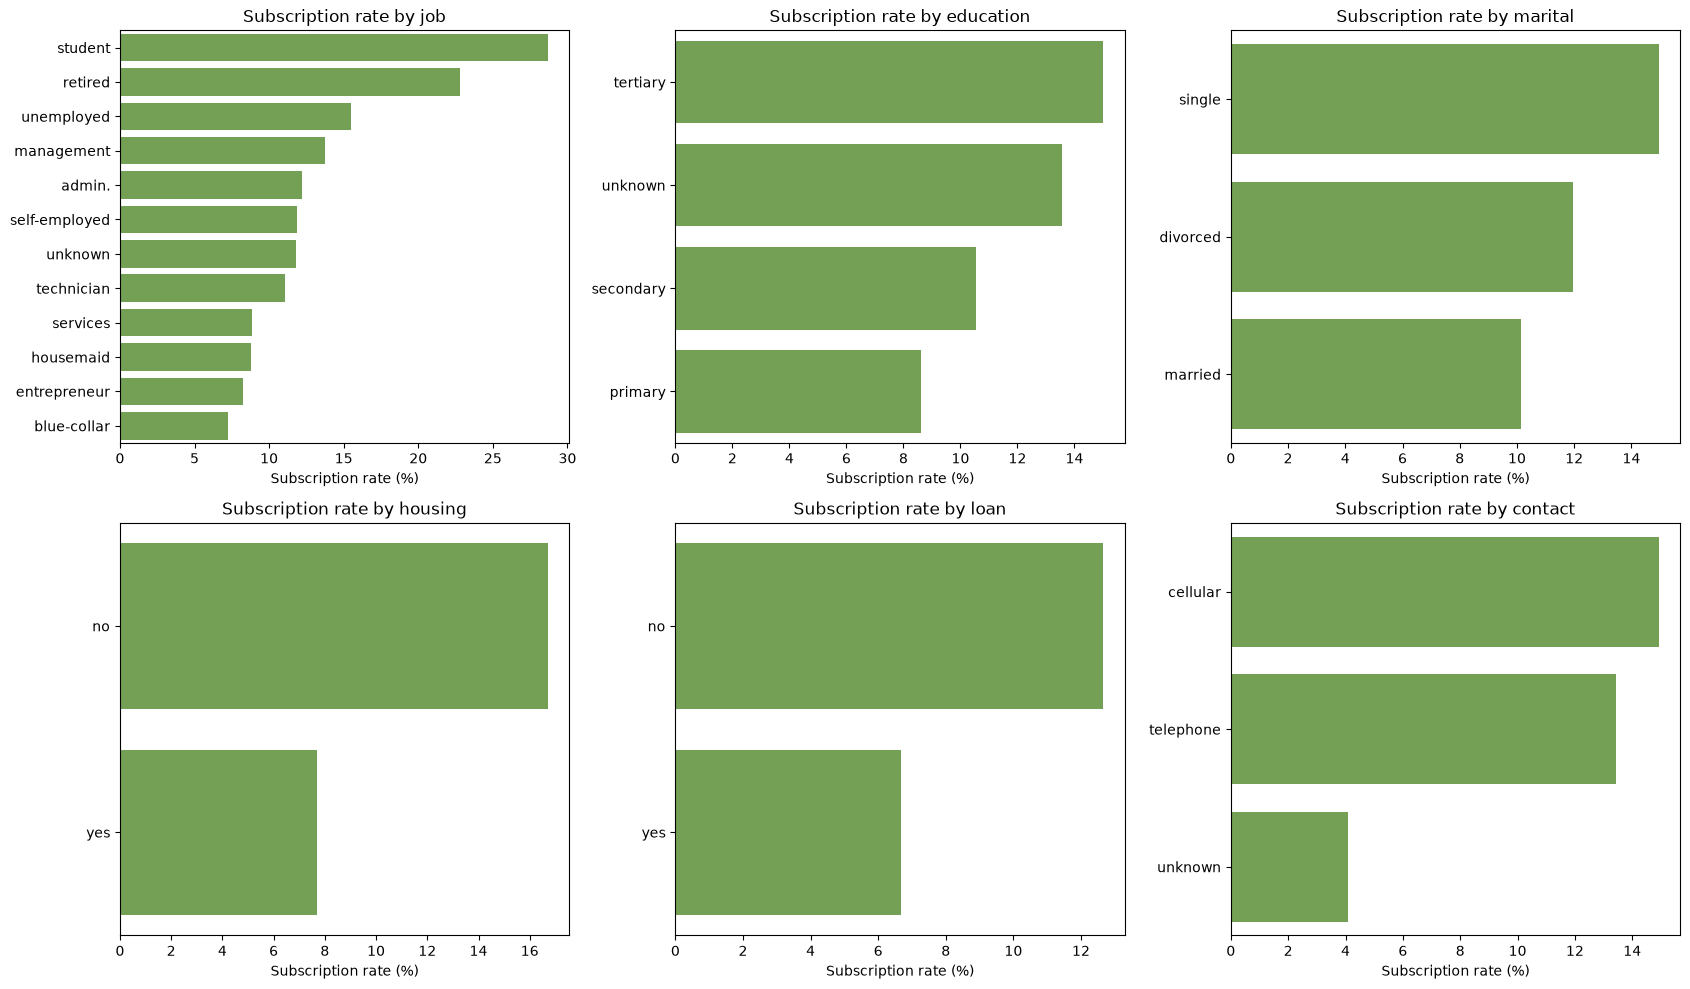

In [26]:
# 4. Categorical feature distributions and conversion rates
categorical_cols = [column for column in df.select_dtypes(include="object").columns if column != "y"]
for column in categorical_cols:
    summary = (
        df.groupby(column, dropna=False)["y"]
        .agg(customers="size", subscriptions=lambda values: (values == "yes").sum())
    )
    summary["subscription_rate_%"] = (summary["subscriptions"] / summary["customers"] * 100).round(2)
    summary = summary.sort_values("subscription_rate_%", ascending=False)
    print(f"\n{column} - categories: {df[column].nunique(dropna=False)}")
    display(summary.head(15))

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
plot_cols = ["job", "education", "marital", "housing", "loan", "contact"]
for axis, column in zip(axes.flat, plot_cols):
    rate = df.groupby(column, dropna=False)["y"].apply(lambda values: (values == "yes").mean() * 100).sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index.astype(str), ax=axis, color="#70AD47")
    axis.set_title(f"Subscription rate by {column}")
    axis.set_xlabel("Subscription rate (%)")
    axis.set_ylabel("")
plt.tight_layout()
plt.show()


Month


,customers,subscription_rate_%
month,,
apr,2932,19.68
aug,6247,11.01
dec,214,46.73
feb,2649,16.65
jan,1403,10.12
jul,6895,9.09
jun,5341,10.22
mar,477,51.99
may,13766,6.72



Contact


,customers,subscription_rate_%
contact,,
cellular,29285,14.92
telephone,2906,13.42
unknown,13020,4.07



Campaign Group


,customers,subscription_rate_%
campaign_group,,
1,17544,14.60
2,12505,11.20
3,5521,11.19
4-5,5286,8.63
6-10,3159,6.52
11+,1196,3.93



Previous Contact


,customers,subscription_rate_%
previously_contacted,,
0,36954,9.16
1,8257,23.07


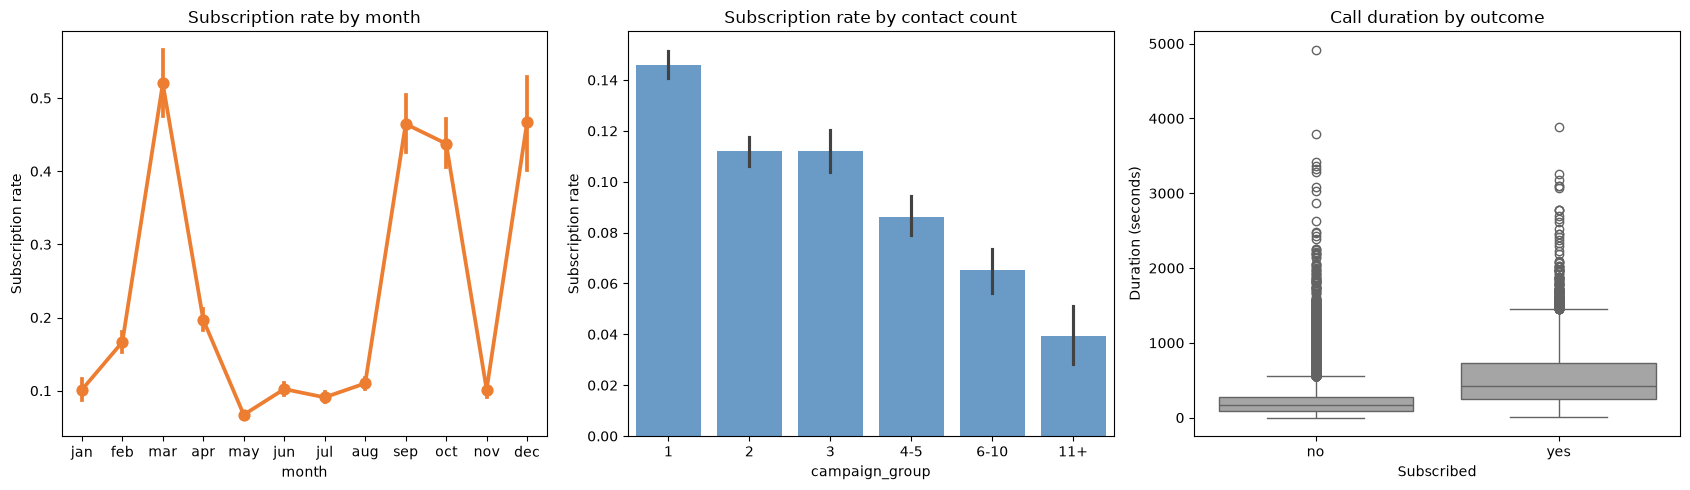

In [27]:
# 5. Campaign and contact-history analysis
df_eda = df.copy()
df_eda["subscribed"] = (df_eda["y"] == "yes").astype(int)
df_eda["previously_contacted"] = (df_eda["pdays"] != -1).astype(int)
df_eda["campaign_group"] = pd.cut(
    df_eda["campaign"],
    bins=[0, 1, 2, 3, 5, 10, np.inf],
    labels=["1", "2", "3", "4-5", "6-10", "11+"],
    include_lowest=True,
 )

scenario_tables = {
    "month": df_eda.groupby("month", observed=False)["subscribed"].agg(customers="size", subscription_rate="mean"),
    "contact": df_eda.groupby("contact", observed=False)["subscribed"].agg(customers="size", subscription_rate="mean"),
    "campaign_group": df_eda.groupby("campaign_group", observed=False)["subscribed"].agg(customers="size", subscription_rate="mean"),
    "previous_contact": df_eda.groupby("previously_contacted")["subscribed"].agg(customers="size", subscription_rate="mean"),
}
for name, table in scenario_tables.items():
    table["subscription_rate_%"] = (table["subscription_rate"] * 100).round(2)
    print(f"\n{name.replace('_', ' ').title()}")
    display(table.drop(columns="subscription_rate"))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.pointplot(data=df_eda, x="month", y="subscribed", order=["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"], ax=axes[0], color="#ED7D31")
axes[0].set_title("Subscription rate by month")
axes[0].set_ylabel("Subscription rate")
sns.barplot(data=df_eda, x="campaign_group", y="subscribed", ax=axes[1], color="#5B9BD5")
axes[1].set_title("Subscription rate by contact count")
axes[1].set_ylabel("Subscription rate")
sns.boxplot(data=df_eda, x="y", y="duration", order=["no", "yes"], ax=axes[2], color="#A5A5A5")
axes[2].set_title("Call duration by outcome")
axes[2].set_xlabel("Subscribed")
axes[2].set_ylabel("Duration (seconds)")
plt.tight_layout()
plt.show()

Age-band performance:


,customers,subscription_rate_%
age_band,,
<=25,1336,23.95
26-35,15571,12.00
36-45,13856,9.39
46-55,9548,9.35
56-65,4149,14.12
66+,751,42.61


Numeric correlation with subscription target:


,correlation
campaign,-0.073172
day,-0.028348
age,0.025155
balance,0.052838
previous,0.093236
pdays,0.103621
duration,0.394521


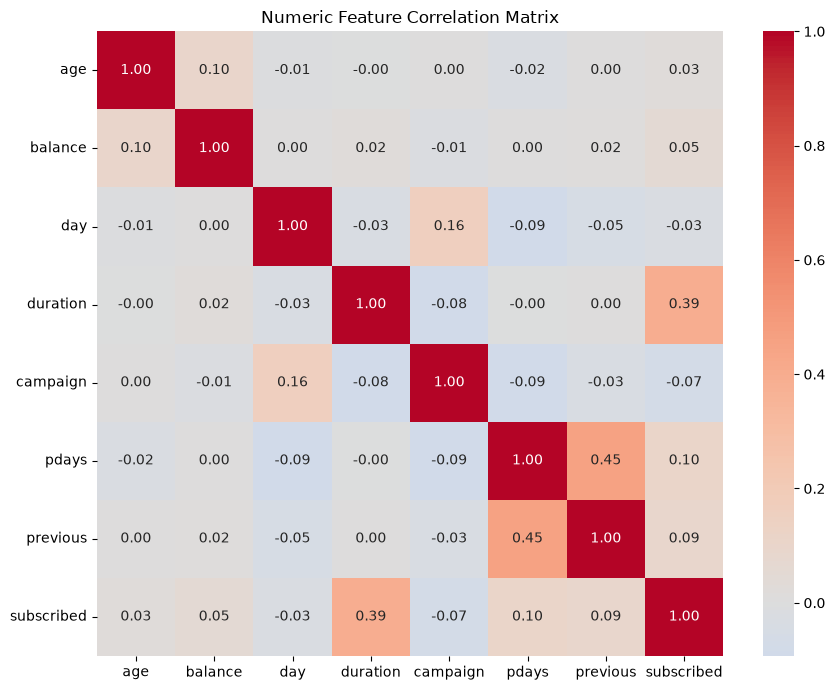

Model-readiness inventory:


,feature,role,type,unique_values,missing_rate_%
0,age,feature,int64,77,0.0
1,job,feature,str,12,0.0
2,marital,feature,str,3,0.0
3,education,feature,str,4,0.0
4,default,feature,str,2,0.0
5,balance,feature,int64,7168,0.0
6,housing,feature,str,2,0.0
7,loan,feature,str,2,0.0
8,contact,feature,str,3,0.0
9,day,feature,int64,31,0.0


In [28]:
# 6. Relationships, interactions, and modelling readiness
df_eda["age_band"] = pd.cut(df_eda["age"], bins=[0, 25, 35, 45, 55, 65, np.inf], labels=["<=25", "26-35", "36-45", "46-55", "56-65", "66+"])
age_table = df_eda.groupby("age_band", observed=False)["subscribed"].agg(customers="size", subscription_rate="mean")
age_table["subscription_rate_%"] = (age_table["subscription_rate"] * 100).round(2)
print("Age-band performance:")
display(age_table.drop(columns="subscription_rate"))

numeric_target_corr = df_eda[numeric_cols + ["subscribed"]].corr(numeric_only=True)["subscribed"].drop("subscribed").sort_values()
print("Numeric correlation with subscription target:")
display(numeric_target_corr.to_frame("correlation"))

plt.figure(figsize=(9, 7))
sns.heatmap(df_eda[numeric_cols + ["subscribed"]].corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()

model_readiness = pd.DataFrame({
    "feature": df.columns,
    "role": ["target" if column == "y" else "feature" for column in df.columns],
    "type": [str(df[column].dtype) for column in df.columns],
    "unique_values": [df[column].nunique(dropna=False) for column in df.columns],
    "missing_rate_%": [round(df[column].isna().mean() * 100, 2) for column in df.columns],
})
print("Model-readiness inventory:")
display(model_readiness)

## EDA conclusions and next steps

- The target is a customer subscription outcome (`y`), not fraud.
- Check the class imbalance before training; accuracy alone will be misleading if `yes` is the minority class.
- Treat `pdays = -1` as a meaningful "not previously contacted" category rather than an ordinary numeric value.
- Inspect `duration` carefully: it is useful for retrospective analysis but may not be available before a call, so exclude it for a true pre-contact model.
- Encode categorical columns, use stratified train/test splitting, and evaluate with ROC-AUC, precision, recall, F1, and PR-AUC.
- Compare campaign performance by segment, but avoid using post-outreach information when building a model intended to prioritize future customers.